Successfully loaded data from ../result/single_person_cat_history_with_reliability.csv


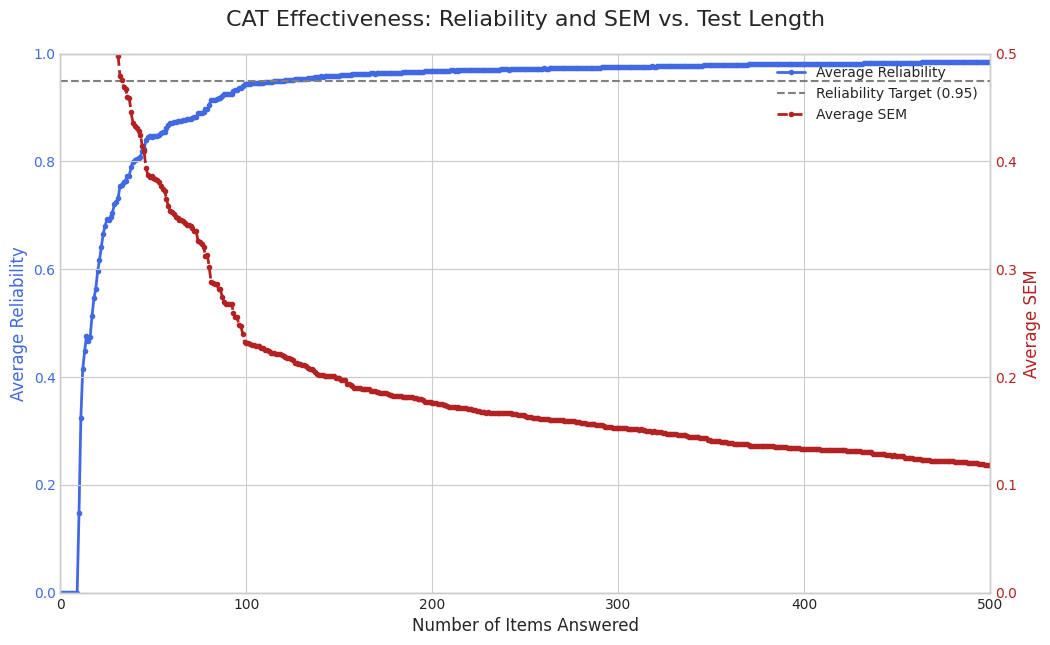

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import numpy as np

# =============================================================================
# 1. LOAD THE SIMULATION HISTORY
# =============================================================================

# Define the path to your results file
output_dir = "../result"
file_path = os.path.join(output_dir, "single_person_cat_history_with_reliability.csv")

# Load the data into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
except FileNotFoundError:
    print(f"ERROR: The file was not found at {file_path}")
    print("Please make sure you have run the previous simulation script successfully.")
    df = None

# =============================================================================
# 2. CALCULATE AVERAGE METRICS
# =============================================================================

if df is not None:
    # Find all SEM and reliability columns in the DataFrame
    sem_cols = [col for col in df.columns if col.startswith('sem_')]
    reliability_cols = [col for col in df.columns if col.startswith('reliability_')]

    # Calculate the average across all dimensions for each step (row)
    df['avg_sem'] = df[sem_cols].mean(axis=1)
    df['avg_reliability'] = df[reliability_cols].mean(axis=1)
    
    # =============================================================================
    # 3. PLOT THE RESULTS WITH FINAL AXIS ADJUSTMENT
    # =============================================================================

    # Create a figure and a primary y-axis for Reliability
    fig, ax1 = plt.subplots(figsize=(12, 7))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Plot Average Reliability
    color = 'royalblue'
    ax1.set_xlabel('Number of Items Answered', fontsize=12)
    ax1.set_ylabel('Average Reliability', color=color, fontsize=12)
    ax1.plot(df['step'], df['avg_reliability'], color=color, marker='.', linestyle='-', linewidth=2, label='Average Reliability')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.0)

    # Add a horizontal line for a common reliability target
    ax1.axhline(y=0.95, color='gray', linestyle='--', label='Reliability Target (0.95)')
    
    # Create a secondary y-axis for SEM
    ax2 = ax1.twinx()
    
    ax2.set_ylim(0, 0.5)
    
    color = 'firebrick'
    ax2.set_ylabel('Average SEM', color=color, fontsize=12)
    ax2.plot(df['step'], df['avg_sem'], color=color, marker='.', linestyle='--', linewidth=2, label='Average SEM')
    ax2.tick_params(axis='y', labelcolor=color)

    # Synchronize the ticks on both y-axes
    ax1.yaxis.set_major_locator(mticker.LinearLocator(numticks=6))
    ax2.yaxis.set_major_locator(mticker.LinearLocator(numticks=6))

    # --- FIX: Manually set the x-axis limits to remove the margin ---
    ax1.set_xlim(0, df['step'].max())

    # Add title and a unified legend
    plt.title('CAT Effectiveness: Reliability and SEM vs. Test Length', fontsize=16, pad=20)
    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))

    plt.show()